In [1]:
#optimized search algorithm with GUI - Result of 1st Sprint
#

import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from collections import deque
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk

def trace_boundary(binary_image):
    """Finds and traces all boundary pixels in a binary image using BFS with 8-connectivity."""
    start_time = time.time()
    
    h, w = binary_image.shape
    boundary_mask = np.zeros((h, w), dtype=np.uint8)  # 0 = not boundary, 255 = boundary
    visited = np.zeros((h, w), dtype=bool)  # Track visited pixels
    labels = np.zeros((h, w), dtype=int)  # Store labels of each boundary pixel
    current_label = 1  # Start labeling from 1

    row_sums = np.sum(binary_image, axis=1)
    col_sums = np.sum(binary_image, axis=0)
    
    top = np.argmax(row_sums > 0)
    bottom = h - np.argmax(row_sums[::-1] > 0)
    left = np.argmax(col_sums > 0)
    right = w - np.argmax(col_sums[::-1] > 0)
    
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]

    def bfs(start_i, start_j):
        queue = deque([(start_i, start_j)])
        
        while queue:
            i, j = queue.popleft()
            
            if visited[i, j]:
                continue
            
            visited[i, j] = True
            boundary_mask[i, j] = 255
            labels[i, j] = current_label

            for dx, dy in directions:
                ni, nj = i + dx, j + dy
                if 0 <= ni < h and 0 <= nj < w and not visited[ni, nj]:
                    if binary_image[ni, nj] == 255:
                        boundary_found = any(0 <= ni + dx2 < h and 0 <= nj + dy2 < w and binary_image[ni + dx2, nj + dy2] == 0 for dx2, dy2 in directions)
                        if boundary_found:
                            queue.append((ni, nj))
    
    for i in range(top, bottom):
        for j in range(left, right):
            if binary_image[i, j] == 255 and not visited[i, j]:
                if any(0 <= i + dx < h and 0 <= j + dy < w and binary_image[i + dx, j + dy] == 0 for dx, dy in directions):
                    bfs(i, j)
                    current_label += 1

    print("--- %s seconds ---" % (time.time() - start_time))
    return boundary_mask, labels, current_label - 1


def compute_circularity(labels, num_labels):
    circularities = {}

    for label in range(1, num_labels + 1):
        # Get coordinates of all pixels with this label
        coords = np.column_stack(np.where(labels == label))
        
        if coords.shape[0] < 2:
            continue  # Skip tiny components
        
        # Compute centroid
        centroid = np.mean(coords, axis=0)

        # Compute Euclidean distances to centroid
        distances = np.linalg.norm(coords - centroid, axis=1)

        # Compute mean and variance
        mean_dist = np.mean(distances)
        std_dist = np.std(distances)

        # Avoid division by zero
        circularity = mean_dist / std_dist if std_dist != 0 else 0

        circularities[label] = circularity

    return circularities

def process_image():
    image_path = entry_path.get()
    erosion_iters = int(entry_iterations.get())
    border_thickness = int(entry_thickness.get())
    
    beans_img = cv2.imread(image_path)
    img_gray = cv2.cvtColor(beans_img, cv2.COLOR_BGR2GRAY)
    
    height, width = img_gray.shape
    border_x = int(height * 0.02)
    border_y = int(width * 0.02)
    img_cropped = img_gray[border_x:height-border_x, border_y:width-border_y]
    
    threshold = 75
    _, img_segmented = cv2.threshold(img_cropped, threshold, 255, cv2.THRESH_BINARY_INV)
    
    kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    img_eroded = cv2.erode(img_segmented, kernel_erode, iterations=erosion_iters)
    
    kernel_open = np.ones((3,3), np.uint8)
    img_opened = cv2.morphologyEx(img_eroded, cv2.MORPH_OPEN, kernel_open)
    
    boundary_mask, labels, num_labels = trace_boundary(img_opened)
    colored_img = cv2.cvtColor(img_opened, cv2.COLOR_GRAY2BGR)
    boundary_mask, labels, num_labels = trace_boundary(img_opened)
    circularities = compute_circularity(labels, num_labels)
    print("Circularities per label:", circularities)
    
    for i in range(border_thickness):
        dilated_mask = cv2.dilate(boundary_mask, np.ones((3,3), np.uint8), iterations=i)
        colored_img[dilated_mask == 255] = [0, 0, 255]
    
    img_original = Image.open(image_path)
    img_original.thumbnail((250, 250))
    img_tk = ImageTk.PhotoImage(img_original)
    label_original.config(image=img_tk)
    label_original.image = img_tk
    
    img_result = Image.fromarray(cv2.cvtColor(colored_img, cv2.COLOR_BGR2RGB))
    img_result.thumbnail((250, 250))
    img_result_tk = ImageTk.PhotoImage(img_result)
    label_result.config(image=img_result_tk)
    label_result.image = img_result_tk
    
    label_count.config(text=f"Boundaries found: {num_labels}")





def select_file():
    filename = filedialog.askopenfilename()
    entry_path.delete(0, tk.END)
    entry_path.insert(0, filename)






root = tk.Tk()
root.geometry("600x400")
root.title("Boundary Detection GUI")

frame_controls = tk.Frame(root)
frame_controls.pack()

label_path = tk.Label(frame_controls, text="Image Path:")
label_path.grid(row=0, column=0)
entry_path = tk.Entry(frame_controls, width=50)
entry_path.grid(row=0, column=1)
entry_path.insert(0, "000000.bmp")
btn_browse = tk.Button(frame_controls, text="Browse", command=select_file)
btn_browse.grid(row=0, column=2)

label_iterations = tk.Label(frame_controls, text="Erosion Iterations:")
label_iterations.grid(row=1, column=0)
entry_iterations = tk.Entry(frame_controls, width=10)
entry_iterations.grid(row=1, column=1)
entry_iterations.insert(0, "15")

label_thickness = tk.Label(frame_controls, text="Border Thickness:")
label_thickness.grid(row=2, column=0)
entry_thickness = tk.Entry(frame_controls, width=10)
entry_thickness.grid(row=2, column=1)
entry_thickness.insert(0, "1")

btn_process = tk.Button(root, text="Process Image", command=process_image)
btn_process.pack()

frame_images = tk.Frame(root)
frame_images.pack()

label_original = tk.Label(frame_images)
label_original.pack(side=tk.LEFT)

label_result = tk.Label(frame_images)
label_result.pack(side=tk.RIGHT)

label_count = tk.Label(root, text="")
label_count.pack()

root.mainloop()






--- 0.022642135620117188 seconds ---
--- 0.02401566505432129 seconds ---
Circularities per label: {1: np.float64(3.093879994066079)}


Mean of Beans: 2.9903422284548045
Variance of Beans: 0.1063376662949815
Mean of Chickpeas: 8.147293757147533
Variance of Chickpeas: 3.2772358381253825


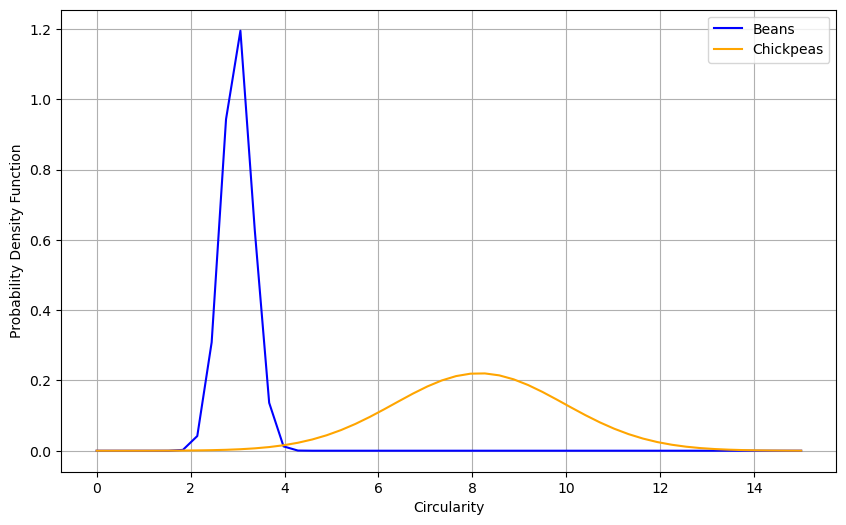

Mean of Beans with ratio of Minor to Major Axis: 0.35699999999999993
Variance of Beans with ratio of Minor to Major Axis: 0.0023209999999999993
Mean of Chickpeas with ratio of Minor to Major Axis: 0.7422222222222222
Variance of Chickpeas with ratio of Minor to Major Axis: 0.00386172839506173


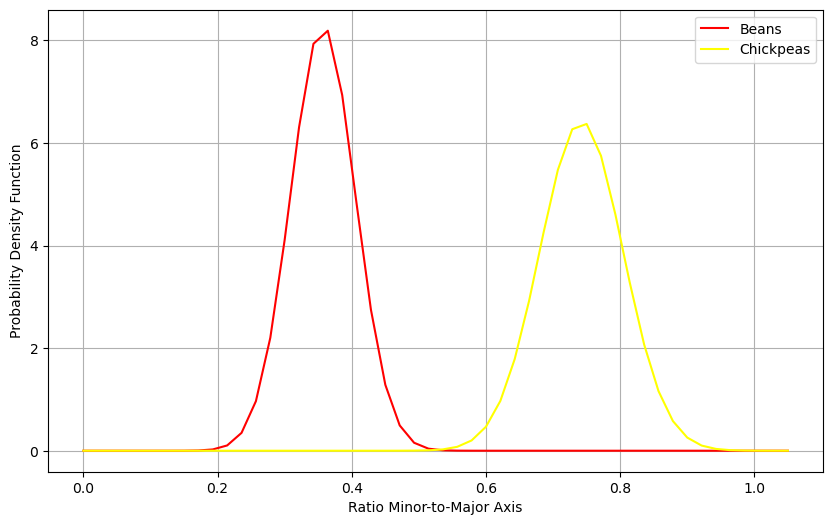

In [10]:
#Calculating the Features Probability Density Functions

import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

circ_beans = np.array([
3.093879994066079,
2.9552764866528953,
2.8105062918903263,
3.0060812043697087,
2.8426192786312945,
2.7114768054467104,
2.6336501477404246,
2.9622526026058926,
3.0080002781506487,
3.8796791949940683
])

circ_chick = np.array([
7.596558513360611,
7.665275555252748,
8.075975474386714,
11.307972535715813,
5.602601767730886,
5.394534672391477,
7.915273838301105,
10.898128562229129,
8.90010073382596,
8.11651591828087,
])

mean_beans_circ = np.mean(circ_beans)
var_beans_circ = np.var(circ_beans)
std_beans_circ = np.std(circ_beans)
print('Mean of Beans:', mean_beans_circ)
print('Variance of Beans:', var_beans_circ)

mean_chick_circ = np.mean(circ_chick)
var_chick_circ = np.var(circ_chick)
std_chick_circ = np.std(circ_chick)
print('Mean of Chickpeas:', mean_chick_circ)
print('Variance of Chickpeas:', var_chick_circ)

x = np.linspace(0, 15)
# Normalverteilungsdichten berechnen
pdf_beans = norm.pdf(x, mean_beans_circ, std_beans_circ)
pdf_chick = norm.pdf(x, mean_chick_circ, std_chick_circ)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, pdf_beans, label='Beans', color='blue')
plt.plot(x, pdf_chick, label='Chickpeas', color='orange')
plt.xlabel('Circularity')
plt.ylabel('Probability Density Function')
plt.legend()
plt.grid(True)
plt.show()


ratio_min_maj_beans = np.array([
0.37,
0.34,
0.33,
0.36,
0.33,
0.32,
0.31,
0.36,
0.36,
0.49
])

ratio_min_maj_chick = np.array([
0.7,
0.68,
0.77,
0.79,
0.61,
0.76,
0.82,
0.78,
0.77
])


mean_beans = np.mean(ratio_min_maj_beans)
var_beans = np.var(ratio_min_maj_beans)
std_beans = np.std(ratio_min_maj_beans)
print('Mean of Beans with ratio of Minor to Major Axis:', mean_beans)
print('Variance of Beans with ratio of Minor to Major Axis:', var_beans)

mean_chick = np.mean(ratio_min_maj_chick)
var_chick = np.var(ratio_min_maj_chick)
std_chick = np.std(ratio_min_maj_chick)
print('Mean of Chickpeas with ratio of Minor to Major Axis:', mean_chick)
print('Variance of Chickpeas with ratio of Minor to Major Axis:', var_chick)

x = np.linspace(0, 1.05)
# Normalverteilungsdichten berechnen
pdf_beans = norm.pdf(x, mean_beans, std_beans)
pdf_chick = norm.pdf(x, mean_chick, std_chick)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, pdf_beans, label='Beans', color='red')
plt.plot(x, pdf_chick, label='Chickpeas', color='yellow')
plt.xlabel('Ratio Minor-to-Major Axis')
plt.ylabel('Probability Density Function')
plt.legend()
plt.grid(True)


plt.show()


In [11]:
# Calculating the probability if an object is an chickpea or a bean 
# based on Bayes Theorem and the Feature Ratio of Minor-to-Major Axis

p_class_beans = 0.5
p_class_chick = 0.5


def object_classification_min_maj_axis(ratio_min_maj_axis):

    p_obj_bean = norm.pdf(ratio_min_maj_axis, mean_beans, std_beans)
    p_obj_chick = norm.pdf(ratio_min_maj_axis, mean_chick, std_chick)

    p_bean_obj = (p_class_beans * p_obj_bean) / (p_class_beans*p_obj_bean+p_class_chick*p_obj_chick)
    p_chick_obj = (p_class_chick * p_obj_chick) / (p_class_beans*p_obj_bean+p_class_chick*p_obj_chick) 

    return p_bean_obj, p_chick_obj
    
p_bean_obj, p_chick_obj = object_classification_min_maj_axis(0.1)

print('Probability it is a bean:', p_bean_obj)

print('Probability it is a chickpea:', p_chick_obj)

Probability it is a bean: 1.0
Probability it is a chickpea: 7.526007367309336e-18


In [12]:
# Calculating the probability if an object is an chickpea or a bean 
# based on Bayes Theorem and the Feature Circularity

p_class_beans = 0.5
p_class_chick = 0.5


def object_classification_circularity(circularity):

    p_obj_bean = norm.pdf(circularity, mean_beans_circ, std_beans_circ)
    p_obj_chick = norm.pdf(circularity, mean_chick_circ, std_chick_circ)

    p_bean_obj = (p_class_beans * p_obj_bean) / (p_class_beans*p_obj_bean+p_class_chick*p_obj_chick)
    p_chick_obj = (p_class_chick * p_obj_chick) / (p_class_beans*p_obj_bean+p_class_chick*p_obj_chick) 

    return p_bean_obj, p_chick_obj
    
p_bean_obj, p_chick_obj = object_classification_circularity(4)

print('Probability it is a bean:', p_bean_obj)

print('Probability it is a chickpea:', p_chick_obj)

Probability it is a bean: 0.38816659727985886
Probability it is a chickpea: 0.6118334027201412


In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from collections import deque
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk

def trace_boundary(binary_image):
    """Finds and traces all boundary pixels in a binary image using BFS with 8-connectivity."""
    start_time = time.time()
    
    h, w = binary_image.shape
    boundary_mask = np.zeros((h, w), dtype=np.uint8)  # 0 = not boundary, 255 = boundary
    visited = np.zeros((h, w), dtype=bool)  # Track visited pixels
    labels = np.zeros((h, w), dtype=int)  # Store labels of each boundary pixel
    current_label = 1  # Start labeling from 1

    row_sums = np.sum(binary_image, axis=1)
    col_sums = np.sum(binary_image, axis=0)
    
    top = np.argmax(row_sums > 0)
    bottom = h - np.argmax(row_sums[::-1] > 0)
    left = np.argmax(col_sums > 0)
    right = w - np.argmax(col_sums[::-1] > 0)
    
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]

    def bfs(start_i, start_j):
        queue = deque([(start_i, start_j)])
        
        while queue:
            i, j = queue.popleft()
            
            if visited[i, j]:
                continue
            
            visited[i, j] = True
            boundary_mask[i, j] = 255
            labels[i, j] = current_label

            for dx, dy in directions:
                ni, nj = i + dx, j + dy
                if 0 <= ni < h and 0 <= nj < w and not visited[ni, nj]:
                    if binary_image[ni, nj] == 255:
                        boundary_found = any(0 <= ni + dx2 < h and 0 <= nj + dy2 < w and binary_image[ni + dx2, nj + dy2] == 0 for dx2, dy2 in directions)
                        if boundary_found:
                            queue.append((ni, nj))
    
    for i in range(top, bottom):
        for j in range(left, right):
            if binary_image[i, j] == 255 and not visited[i, j]:
                if any(0 <= i + dx < h and 0 <= j + dy < w and binary_image[i + dx, j + dy] == 0 for dx, dy in directions):
                    bfs(i, j)
                    current_label += 1

    print("--- %s seconds ---" % (time.time() - start_time))
    return boundary_mask, labels, current_label - 1

def calculate_axes_and_ratio(labels, num_labels):
    ratios = {}

    for label in range(1, num_labels + 1):
        points = np.argwhere(labels == label)
        if len(points) < 2:
            continue

        pts = points[:, [1, 0]]  # (x, y)

        # Asse maggiore: trovamento dei due punti più distanti
        max_dist = 0
        for i in range(len(pts)):
            for j in range(i+1, len(pts)):
                dist = np.linalg.norm(pts[i] - pts[j])
                if dist > max_dist:
                    max_dist = dist
                    pt1, pt2 = pts[i], pts[j]

        # Calcolo del punto medio
        midpoint = (pt1 + pt2) // 2
        midpoint = midpoint.astype(int)

        # Vettore unitario dell'asse maggiore
        major_vec = pt2 - pt1
        major_unit = major_vec / np.linalg.norm(major_vec)

        # Vettore perpendicolare (ruotato di 90°)
        perp_unit = np.array([-major_unit[1], major_unit[0]])

        # Proiezione dei punti sull'asse perpendicolare
        projections = []
        for p in pts:
            rel_vec = p - midpoint
            proj_len = np.dot(rel_vec, perp_unit)
            proj_point = midpoint + proj_len * perp_unit
            projections.append((proj_len, proj_point))

        # Ordina e filtra i punti proiettati validi (all'interno del fagiolo)
        projections.sort(key=lambda x: x[0])
        valid_proj_points = [p for _, p in projections if 0 <= int(p[1]) < labels.shape[0] and
                             0 <= int(p[0]) < labels.shape[1] and
                             labels[int(p[1]), int(p[0])] == label]

        if len(valid_proj_points) < 2:
            continue

        min_proj = valid_proj_points[0]
        max_proj = valid_proj_points[-1]

        # Calcola le lunghezze degli assi
        major_len = np.linalg.norm(pt2 - pt1)
        minor_len = np.linalg.norm(max_proj - min_proj)

        # Rapporto: asse minore / asse maggiore => valore tra 0 e 1
        ratio = minor_len / major_len if major_len != 0 else 0
        ratios[label] = ratio

    return ratios

def object_classification_min_maj_axis(ratio):
    """Classify object based on minor/major axis ratio"""
    # Chickpeas are more circular (higher ratio)
    # Beans are more elongated (lower ratio)
    chickpea_prob = ratio  # Higher ratio -> more likely to be chickpea
    bean_prob = 1 - ratio  # Lower ratio -> more likely to be bean
    return (bean_prob, chickpea_prob)

def process_image():
    image_path = entry_path.get()
    erosion_iters = int(entry_iterations.get())
    border_thickness = int(entry_thickness.get())
    
    beans_img = cv2.imread(image_path)
    img_gray = cv2.cvtColor(beans_img, cv2.COLOR_BGR2GRAY)
    
    height, width = img_gray.shape
    border_x = int(height * 0.02)
    border_y = int(width * 0.02)
    img_cropped = img_gray[border_x:height-border_x, border_y:width-border_y]
    
    threshold = 75
    _, img_segmented = cv2.threshold(img_cropped, threshold, 255, cv2.THRESH_BINARY_INV)
    
    kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    img_eroded = cv2.erode(img_segmented, kernel_erode, iterations=erosion_iters)
    
    kernel_open = np.ones((3,3), np.uint8)
    img_opened = cv2.morphologyEx(img_eroded, cv2.MORPH_OPEN, kernel_open)
    
    boundary_mask, labels, num_labels = trace_boundary(img_opened)
    colored_img = cv2.cvtColor(img_opened, cv2.COLOR_GRAY2BGR)
    
    ratios = calculate_axes_and_ratio(labels, num_labels)
    bean_count = 0
    chickpea_count = 0
    certainties = {}
    kernel = np.ones((3,3), np.uint8)

    # Determiniamo i colori per ogni label
    label_colors = {}
    for label, rat in ratios.items():
        p_bean, p_chick = object_classification_min_maj_axis(rat)
        
        if p_bean > p_chick:
            label_colors[label] = (0, 255, 0)  # Verde per Bean
            bean_count += 1
            certainties[label] = p_bean
        else:
            label_colors[label] = (0, 0, 255)   # Rosso per Chickpea
            chickpea_count += 1
            certainties[label] = p_chick

    # Coloriamo i bordi per ogni label
    for label, color in label_colors.items():
        # Creiamo una maschera per il bordo del label corrente
        mask = (labels == label) & (boundary_mask == 255)
        mask_uint8 = mask.astype(np.uint8) * 255
        
        # Dilatiamo la maschera per lo spessore del bordo
        if border_thickness > 0:
            dilated_mask = cv2.dilate(mask_uint8, kernel, iterations=border_thickness)
        else:
            dilated_mask = mask_uint8
        
        # Applica il colore
        colored_img[dilated_mask > 0] = color
    
    certainty = np.mean(list(certainties.values())) * 100
    
    img_original = Image.open(image_path)
    img_original.thumbnail((250, 250))
    img_tk = ImageTk.PhotoImage(img_original)
    label_original.config(image=img_tk)
    label_original.image = img_tk
    
    img_result = Image.fromarray(cv2.cvtColor(colored_img, cv2.COLOR_BGR2RGB))
    img_result.thumbnail((250, 250))
    img_result_tk = ImageTk.PhotoImage(img_result)
    label_result.config(image=img_result_tk)
    label_result.image = img_result_tk
    
    # Creiamo un frame separato per i conteggi con colori diversi
    count_frame = tk.Frame(root)
    count_frame.pack()
    
    tk.Label(count_frame, text="Boundaries found:", font=("Helvetica", 14, "bold")).grid(row=0, column=0, sticky="w")
    tk.Label(count_frame, text=str(num_labels), font=("Helvetica", 14)).grid(row=0, column=1, sticky="w")
    
    tk.Label(count_frame, text="Chickpeas:", font=("Helvetica", 14, "bold"), fg="red").grid(row=1, column=0, sticky="w")
    tk.Label(count_frame, text=str(chickpea_count), font=("Helvetica", 14), fg="red").grid(row=1, column=1, sticky="w")
    
    tk.Label(count_frame, text="Beans:", font=("Helvetica", 14, "bold"), fg="green").grid(row=2, column=0, sticky="w")
    tk.Label(count_frame, text=str(bean_count), font=("Helvetica", 14), fg="green").grid(row=2, column=1, sticky="w")
    
    tk.Label(count_frame, text="Certainty:", font=("Helvetica", 14, "bold")).grid(row=3, column=0, sticky="w")
    tk.Label(count_frame, text=f"{certainty:.2f}%", font=("Helvetica", 14)).grid(row=3, column=1, sticky="w")
    
    # Rimuoviamo il vecchio label_count se esiste
    if hasattr(root, 'count_frame'):
        root.count_frame.pack_forget()
    root.count_frame = count_frame

def select_file():
    filename = filedialog.askopenfilename()
    entry_path.delete(0, tk.END)
    entry_path.insert(0, filename)

root = tk.Tk()
root.geometry("700x600")
root.title("Object Classification GUI (Ratio)")

frame_controls = tk.Frame(root, padx=10, pady=10)
frame_controls.pack()

label_path = tk.Label(frame_controls, text="Image Path:")
label_path.grid(row=0, column=0, sticky="e", padx=5, pady=5)
entry_path = tk.Entry(frame_controls, width=50)
entry_path.grid(row=0, column=1, padx=5, pady=5)
entry_path.insert(0, "../imgs/chick_2.bmp")
btn_browse = tk.Button(frame_controls, text="Browse", command=select_file)
btn_browse.grid(row=0, column=2, padx=5, pady=5)

label_iterations = tk.Label(frame_controls, text="Erosion Iterations:")
label_iterations.grid(row=1, column=0, sticky="e", padx=5, pady=5)
entry_iterations = tk.Entry(frame_controls, width=10)
entry_iterations.grid(row=1, column=1, sticky="w", padx=5, pady=5)
entry_iterations.insert(0, "15")

label_thickness = tk.Label(frame_controls, text="Border Thickness:")
label_thickness.grid(row=2, column=0, sticky="e", padx=5, pady=5)
entry_thickness = tk.Entry(frame_controls, width=10)
entry_thickness.grid(row=2, column=1, sticky="w", padx=5, pady=5)
entry_thickness.insert(0, "1")

btn_process = tk.Button(root, text="Process Image", command=process_image, font=("Helvetica", 12))
btn_process.pack(pady=10)

frame_images = tk.Frame(root)
frame_images.pack(pady=10)

label_original = tk.Label(frame_images, text="Original Image")
label_original.pack(side=tk.LEFT, padx=20)

label_result = tk.Label(frame_images, text="Processed Image")
label_result.pack(side=tk.RIGHT, padx=20)

# Frame per i risultati (verrà sostituito durante l'elaborazione)
root.count_frame = tk.Frame(root)
root.count_frame.pack()

root.mainloop()

--- 0.14494061470031738 seconds ---
--- 0.04399538040161133 seconds ---
--- 0.07706189155578613 seconds ---
--- 0.06280255317687988 seconds ---


C:\Users\decap\miniconda3\envs\open3d_env\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\decap\miniconda3\envs\open3d_env\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


--- 0.04372525215148926 seconds ---
--- 0.04046225547790527 seconds ---
--- 0.03800678253173828 seconds ---
--- 0.0764012336730957 seconds ---
--- 0.043480634689331055 seconds ---
--- 0.022194623947143555 seconds ---
--- 0.023883819580078125 seconds ---
--- 0.023499727249145508 seconds ---
--- 0.023819446563720703 seconds ---
